# Сравнение VI и PI для разных θ

1. Сначала в ноутбуке `asymptotics_vi_pi.ipynb` запускаются вычисления (для одного или нескольких значений θ) — в конце он сохраняет JSON `results_asymptotics_vi_pi_*.json`.
2. Затем этот ноутбук автоматически находит все такие JSON, читает из них θ и строит по одному графику VI и PI на каждый запуск (сабплоты по горизонтали). В конце сохраняются рисунки и агрегированный JSON.


In [1]:
import sys
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from contextlib import redirect_stdout
import os

# Настройка пути к корню проекта, как в asymptotics_vi_pi.ipynb
root = Path.cwd().parent if Path.cwd().name == "experiments" else Path.cwd()
sys.path.insert(0, str(root))

from src.environment import ParkourEnv
from src.algorithms import ValueIteration, PolicyIteration
from src.landscape import generate_height_map, build_graph, dijkstra

# Параметры эксперимента
THETAS = [0.1, 1e-3, 1e-6]
GAMMA = 0.99
MAX_JUMP_UP = 3
SAFE_JUMP_DOWN = 1
MIN_HEIGHT, MAX_HEIGHT = 1, 10
SEED_BASE = 42
MAX_GRID_SIZE = 10  # максимум размера сетки n (n×n)
N_MAPS = 5         # сколько карт на каждый размер сетки для усреднения времени

rewards = {"victory": 100, "death": -100, "step": -1}

all_data = []  # сюда собираем результаты для всех θ

for theta in THETAS:
    algo_config_vi = {"gamma": GAMMA, "theta": theta, "max_iters": 50000}
    algo_config_pi = {"gamma": GAMMA, "theta": theta, "max_eval_iters": 5000}

    results = []

    for grid_size in range(2, MAX_GRID_SIZE + 1):
        start = (0, 0)
        end = (grid_size - 1, grid_size - 1)
        times_vi, times_pi = [], []

        for map_idx in range(N_MAPS):
            attempt = 0
            while True:
                seed = SEED_BASE + grid_size * 10000 + map_idx * 1000 + attempt
                height_map = generate_height_map(grid_size, MIN_HEIGHT, MAX_HEIGHT, seed)
                graph = build_graph(height_map, MAX_JUMP_UP, SAFE_JUMP_DOWN)
                total_damage, path = dijkstra(graph, start, end)
                if path is not None and total_damage != float("inf"):
                    break
                attempt += 1

            hp_start = int(total_damage) + 1
            env_config = {
                "height_map": height_map.tolist(),
                "hp_start": hp_start,
                "rewards": rewards,
                "max_jump_up": MAX_JUMP_UP,
                "safe_jump_down": SAFE_JUMP_DOWN,
            }

            env = ParkourEnv(env_config)
            n_states = env.rows * env.cols * (env.hp_start + 1)

            algo_vi = ValueIteration(env, algo_config_vi)
            with open(os.devnull, "w") as fnull, redirect_stdout(fnull):
                info_vi = algo_vi.solve()
            times_vi.append(info_vi["time"])

            env2 = ParkourEnv(env_config)
            algo_pi = PolicyIteration(env2, algo_config_pi)
            with open(os.devnull, "w") as fnull, redirect_stdout(fnull):
                info_pi = algo_pi.solve()
            times_pi.append(info_pi["time"])

        time_vi_mean = np.mean(times_vi)
        time_pi_mean = np.mean(times_pi)
        time_vi_std = np.std(times_vi)
        time_pi_std = np.std(times_pi)

        results.append({
            "grid_size": grid_size,
            "n_states": n_states,
            "min_damage": total_damage,
            "hp_start": hp_start,
            "time_vi": float(time_vi_mean),
            "time_pi": float(time_pi_mean),
            "time_vi_std": float(time_vi_std),
            "time_pi_std": float(time_pi_std),
        })
        print(f"θ={theta}, grid {grid_size}x{grid_size}: {N_MAPS} maps, VI={time_vi_mean:.4f}s ± {time_vi_std:.4f}, PI={time_pi_mean:.4f}s ± {time_pi_std:.4f}")

    all_data.append({
        "label": f"θ = {theta}",
        "theta": theta,
        "n_maps": N_MAPS,
        "results": results,
    })

print("Всего запусков:", len(all_data))
for d in all_data:
    print(f"  {d['label']}: points={len(d['results'])}")


/Users/vasilij/Documents/RL_proj3/Parkour/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  1%|▏         | 688/50000 [00:00<00:00, 127195.36it/s]
2it [00:00, 501.23it/s, delta=9.64e-02]
  1%|▏         | 688/50000 [00:00<00:00, 140204.12it/s]
3it [00:00, 382.99it/s, delta=9.63e-02]
  1%|▏         | 688/50000 [00:00<00:00, 144565.96it/s]
3it [00:00, 626.83it/s, delta=9.44e-02]
  1%|▏         | 688/50000 [00:00<00:00, 154994.15it/s]
3it [00:00, 417.30it/s, delta=9.72e-02]
  1%|▏         | 688/50000 [00:00<00:00, 131442.16it/s]
3it [00:00, 834.08it/s, delta=9.44e-02]
  1%|▏         | 688/50000 [00:00<00:00, 157877.29it/s]
5it [00:00, 564.07it/s, delta=9.16e-02]
  1%|▏         | 688/50000 [00:00<00:00, 116805.55it/s]
4it [00:00, 509.62it/s, delta=9.44e-02]
  1%|▏         | 688/50000 [00:00<00:00, 12432

θ=0.1, grid 2x2: 5 maps, VI=0.0076s ± 0.0038, PI=0.0063s ± 0.0017
θ=0.1, grid 3x3: 5 maps, VI=0.0062s ± 0.0008, PI=0.0078s ± 0.0018
θ=0.1, grid 4x4: 5 maps, VI=0.0081s ± 0.0028, PI=0.0088s ± 0.0008


  1%|▏         | 688/50000 [00:00<00:00, 71163.53it/s]
9it [00:00, 908.08it/s, delta=7.92e-02]
  1%|▏         | 688/50000 [00:00<00:00, 129734.35it/s]
8it [00:00, 733.96it/s, delta=8.89e-02]
  1%|▏         | 688/50000 [00:00<00:00, 72399.05it/s]
9it [00:00, 927.92it/s, delta=8.41e-02]
  1%|▏         | 688/50000 [00:00<00:00, 133355.57it/s]
9it [00:00, 954.99it/s, delta=8.28e-02]
  1%|▏         | 688/50000 [00:00<00:00, 59737.53it/s]
13it [00:00, 1180.85it/s, delta=7.76e-02]
  1%|▏         | 688/50000 [00:00<00:00, 60686.02it/s]
11it [00:00, 883.82it/s, delta=7.87e-02]
  1%|▏         | 688/50000 [00:00<00:00, 65380.09it/s]
10it [00:00, 881.06it/s, delta=7.68e-02]
  1%|▏         | 688/50000 [00:00<00:00, 68221.03it/s]
12it [00:00, 833.04it/s, delta=3.98e-02]
  1%|▏         | 688/50000 [00:00<00:00, 69055.26it/s]
14it [00:00, 962.20it/s, delta=3.78e-02] 
  1%|▏         | 688/50000 [00:00<00:00, 61570.39it/s]
10it [00:00, 733.95it/s, delta=3.49e-02]
  1%|▏         | 688/50000 [00:00<00:00,

θ=0.1, grid 5x5: 5 maps, VI=0.0101s ± 0.0045, PI=0.0104s ± 0.0007
θ=0.1, grid 6x6: 5 maps, VI=0.0115s ± 0.0006, PI=0.0134s ± 0.0015


12it [00:00, 1056.88it/s, delta=7.53e-02]
  1%|▏         | 688/50000 [00:00<00:00, 58349.63it/s]
14it [00:00, 1176.26it/s, delta=7.19e-02]
  1%|▏         | 688/50000 [00:00<00:00, 71413.61it/s]
12it [00:00, 817.44it/s, delta=7.72e-02]
  1%|▏         | 688/50000 [00:00<00:01, 41722.30it/s]
13it [00:00, 656.23it/s, delta=3.83e-05]
  1%|▏         | 688/50000 [00:00<00:01, 45687.71it/s]
15it [00:00, 746.87it/s, delta=3.28e-02]
  1%|▏         | 688/50000 [00:00<00:00, 51954.94it/s]
11it [00:00, 666.22it/s, delta=6.67e-02]
  1%|▏         | 688/50000 [00:00<00:00, 61659.85it/s]
18it [00:00, 833.88it/s, delta=7.06e-02]
  1%|▏         | 688/50000 [00:00<00:01, 43911.39it/s]
14it [00:00, 927.65it/s, delta=7.02e-02]
  1%|▏         | 688/50000 [00:00<00:00, 54249.26it/s]
18it [00:00, 1141.39it/s, delta=6.22e-02]
  0%|          | 0/50000 [00:00<?, ?it/s]

...

θ=1e-06, grid 8x8: 5 maps, VI=0.0300s ± 0.0025, PI=0.0301s ± 0.0039


  4%|▎         | 1833/50000 [00:00<00:01, 35065.40it/s]
18it [00:00, 310.31it/s, delta=6.01e-07]
  4%|▎         | 1833/50000 [00:00<00:01, 30924.08it/s]
23it [00:00, 501.19it/s, delta=5.54e-07]
  4%|▎         | 1833/50000 [00:00<00:01, 43706.31it/s]
14it [00:00, 415.17it/s, delta=6.78e-07]
  4%|▎         | 1833/50000 [00:00<00:01, 25926.04it/s]
22it [00:00, 544.36it/s, delta=4.10e-07]
  4%|▎         | 1833/50000 [00:00<00:01, 28102.77it/s]


θ=1e-06, grid 9x9: 5 maps, VI=0.0501s ± 0.0089, PI=0.0442s ± 0.0091


20it [00:00, 550.56it/s, delta=5.33e-07]
  4%|▎         | 1833/50000 [00:00<00:01, 44618.96it/s]
17it [00:00, 413.51it/s, delta=5.17e-07]
  4%|▎         | 1833/50000 [00:00<00:01, 34815.46it/s]
19it [00:00, 543.76it/s, delta=2.73e-07]
  4%|▎         | 1833/50000 [00:00<00:00, 49742.55it/s]
16it [00:00, 562.78it/s, delta=6.25e-07]

θ=1e-06, grid 10x10: 5 maps, VI=0.0541s ± 0.0132, PI=0.0371s ± 0.0043
Всего запусков: 3
  θ = 0.1: points=9
  θ = 0.001: points=9
  θ = 1e-06: points=9


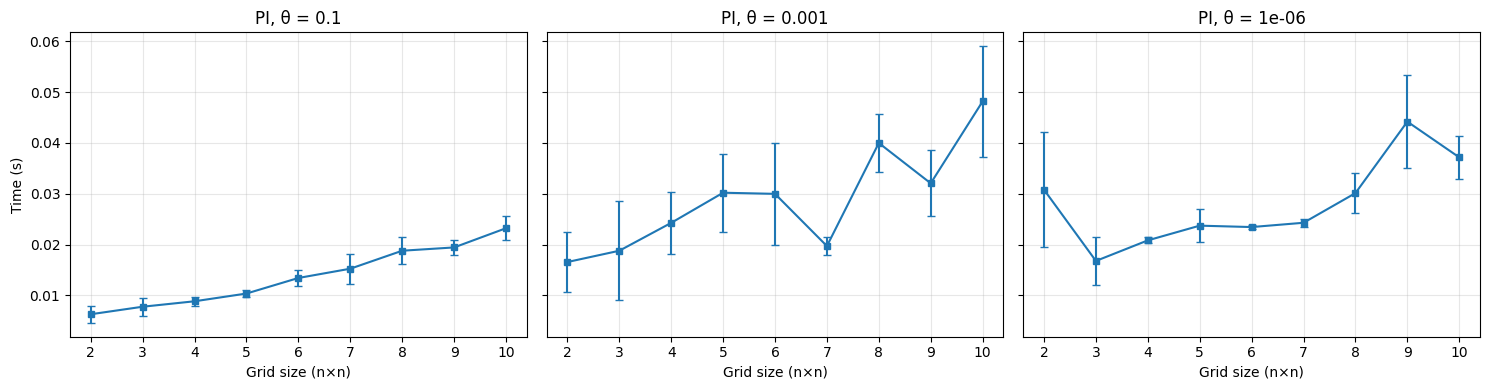

In [2]:
# 3 графика PI по горизонтали
fig_pi, axes_pi = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, d in zip(axes_pi, all_data):
    label = d["label"]
    results = d["results"]

    grid_sizes = [r["grid_size"] for r in results]
    time_pi = [r["time_pi"] for r in results]
    time_pi_std = [r.get("time_pi_std", 0.0) for r in results]

    ax.errorbar(
        grid_sizes,
        time_pi,
        yerr=time_pi_std,
        fmt="s-",
        markersize=5,
        capsize=3,
        label="PI",
    )
    ax.set_title(f"PI, {label}")
    ax.set_xlabel("Grid size (n×n)")
    ax.grid(True, alpha=0.3)

axes_pi[0].set_ylabel("Time (s)")
plt.tight_layout()
plt.show()


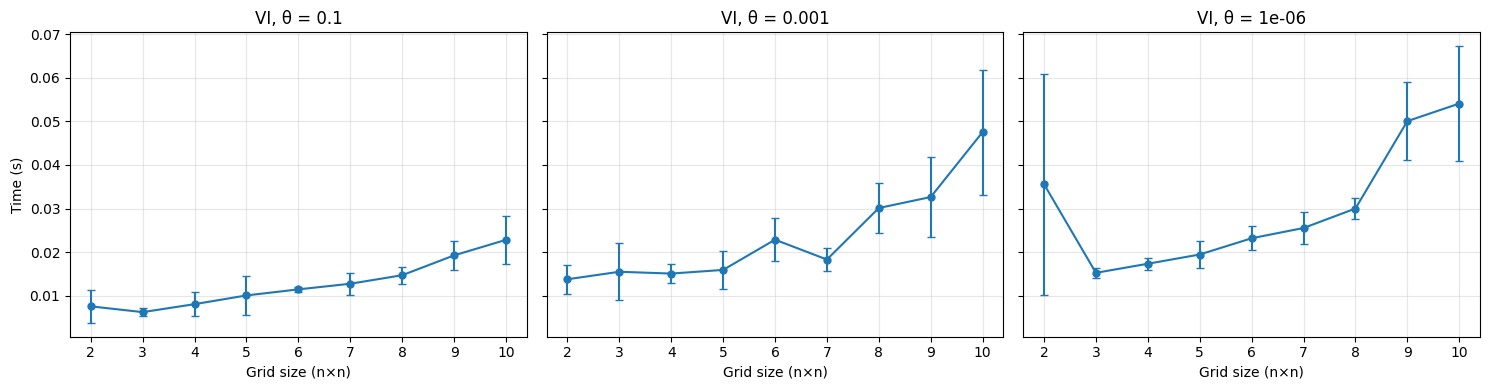

In [3]:
# 3 графика VI по горизонтали
fig_vi, axes_vi = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, d in zip(axes_vi, all_data):
    label = d["label"]
    results = d["results"]

    grid_sizes = [r["grid_size"] for r in results]
    time_vi = [r["time_vi"] for r in results]
    time_vi_std = [r.get("time_vi_std", 0.0) for r in results]

    ax.errorbar(
        grid_sizes,
        time_vi,
        yerr=time_vi_std,
        fmt="o-",
        markersize=5,
        capsize=3,
        label="VI",
    )
    ax.set_title(f"VI, {label}")
    ax.set_xlabel("Grid size (n×n)")
    ax.grid(True, alpha=0.3)

axes_vi[0].set_ylabel("Time (s)")
plt.tight_layout()
plt.show()


In [4]:
# Сохранение объединённых результатов и графиков

from pathlib import Path
BASE_DIR = Path.cwd()
RESULTS_JSON_DIR = BASE_DIR / "results" / "json"
RESULTS_IMG_DIR = BASE_DIR / "results" / "img"
RESULTS_JSON_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_IMG_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Сохраняем агрегированные данные
out_json = RESULTS_JSON_DIR / f"compare_thetas_vi_pi_{timestamp}.json"
with open(out_json, "w", encoding="utf-8") as f:
    json.dump({"runs": all_data}, f, indent=2)

# Сохраняем последние построенные фигуры (VI и PI)
pi_png = RESULTS_IMG_DIR / f"compare_thetas_PI_{timestamp}.png"
vi_png = RESULTS_IMG_DIR / f"compare_thetas_VI_{timestamp}.png"
fig_pi.savefig(pi_png, dpi=150, bbox_inches="tight")
fig_vi.savefig(vi_png, dpi=150, bbox_inches="tight")

print("Сохранены файлы:")
print("  ", out_json)
print("  ", pi_png)
print("  ", vi_png)


NameError: name 'RESULTS_IMG_DIR' is not defined